In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score

In [3]:
# Load CICIDS 2017 dataset (assuming it's a CSV file)
data = pd.read_csv('cicids2017_cleaned.csv')

In [4]:
data.shape

(2520751, 53)

In [5]:
data.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [6]:
# Preprocessing
# Assuming the label is in the 'Label' column
X = data.drop('Attack Type', axis=1).values  # Features
y = data['Attack Type'].values  # Target labels

# Scale the features (normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert labels to categorical for multiclass classification
y_encoded = pd.get_dummies(y).values  # Convert to one-hot encoding

In [7]:
# Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [8]:
# Reshaping the data for LSTM input (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

c:\Users\user15\Anaconda3\envs\vivek\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 0.9680 - loss: 0.0952 - val_accuracy: 0.9814 - val_loss: 0.0413
Epoch 2/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9809 - loss: 0.0438 - val_accuracy: 0.9849 - val_loss: 0.0372
Epoch 3/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9833 - loss: 0.0383 - val_accuracy: 0.9826 - val_loss: 0.0377
Epoch 4/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 0.9842 - loss: 0.0366 - val_accuracy: 0.9869 - val_loss: 0.0331
Epoch 5/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 0.9853 - loss: 0.0346 - val_accuracy: 0.9870 - val_loss: 0.0311
Epoch 6/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9873 - loss: 0.0318 - val_accuracy: 0.9931 - val_loss: 0.0219
Epoch 7/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9896 - loss: 0.0276 - val_accuracy: 0.9898 - val_loss: 0.0270
Epoch 8/10
27571/27571 ━━━━━━━━━━━━━━━━━━━━ 53s 2ms/step - accuracy: 

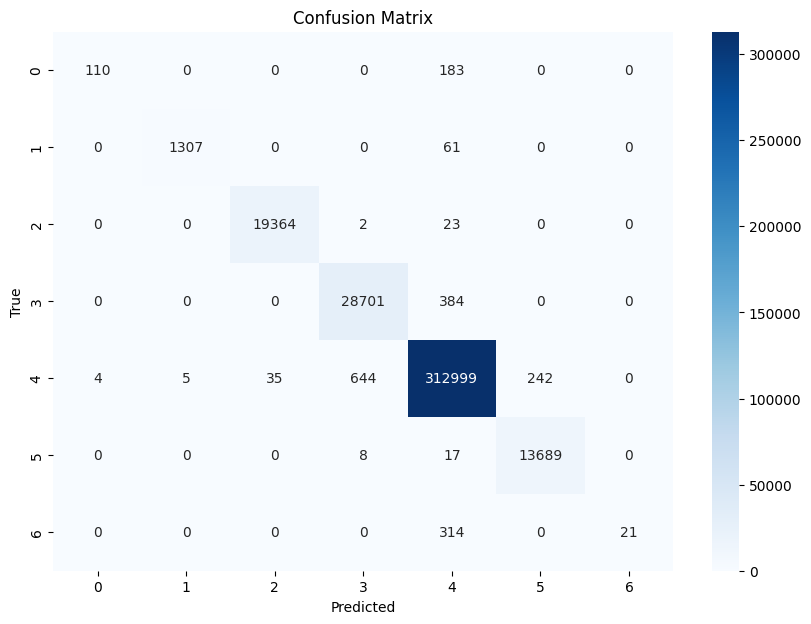

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.38      0.54       293
           1       1.00      0.96      0.98      1368
           2       1.00      1.00      1.00     19389
           3       0.98      0.99      0.98     29085
           4       1.00      1.00      1.00    313929
           5       0.98      1.00      0.99     13714
           6       1.00      0.06      0.12       335

    accuracy                           0.99    378113
   macro avg       0.99      0.77      0.80    378113
weighted avg       0.99      0.99      0.99    378113



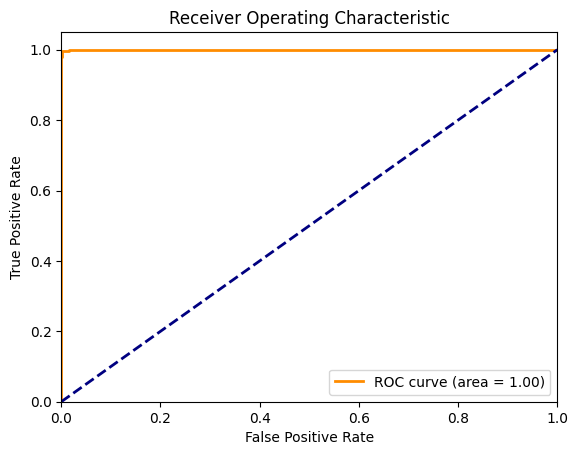

In [9]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Output layer (multiclass)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=64)

# Evaluate the model on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test_classes), yticklabels=np.unique(y_test_classes))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test_classes, y_pred_classes))

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test_classes, y_pred[:, 1], pos_label=1)  # Use the second class for binary classification
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()